# Imports

In [6]:
# =============================================================================
# Imports and environment setup
# =============================================================================
import os
import sys
import time
import csv
import logging
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

# Make the kernel robust if launched through VSCode/Jupyter rather than
# from an already activated conda shell.
CONDA_PREFIX = Path(sys.executable).resolve().parents[1]

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTHONNOUSERSITE"] = "1"

# Make conda libraries preferred inside Jupyter.
# This is important on Juno because scipy/sklearn may otherwise pick up
# /opt/ohpc/pub/apps/miniconda3/lib/libstdc++.so.6 and fail with GLIBCXX_3.4.30.
os.environ["LD_LIBRARY_PATH"] = (
    f"{CONDA_PREFIX / 'lib'}:" + os.environ.get("LD_LIBRARY_PATH", "")
)

import numpy as np
import pandas as pd
import scipy
import scipy.optimize
import anndata as ad
import scanpy as sc
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn import metrics as sk_metrics

import INSTINCT

try:
    from IPython.display import display
except Exception:
    display = print

print("Python:", sys.executable)
print("CONDA_PREFIX:", CONDA_PREFIX)
print("INSTINCT:", INSTINCT.__file__)
print("torch:", torch.__version__, "cuda:", torch.version.cuda, "available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
print("scanpy:", sc.__version__)
print("anndata:", ad.__version__)
print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("scipy:", scipy.__version__)


Python: /work/dal875013/conda_envs/instinct_env/bin/python
CONDA_PREFIX: /work/dal875013/conda_envs/instinct_env
INSTINCT: /work/dal875013/conda_envs/instinct_env/lib/python3.10/site-packages/INSTINCT/__init__.py
torch: 1.13.1+cu117 cuda: 11.7 available: True
GPU: NVIDIA A30
scanpy: 1.9.8
anndata: 0.10.5.post1
numpy: 1.26.4
pandas: 1.5.3
scipy: 1.12.0


# USER CONFIGURATION — edit these to match your environment

In [7]:
# =============================================================================
# USER CONFIGURATION
# =============================================================================

# Path to cloned INSTINCT repo
INSTINCT_ROOT = Path(r"/work/dal875013/projects/mocha/methods/INSTINCT")

# Path to the folder containing SCE_151*.h5ad files
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")

# Output folder. The benchmark is intentionally limited to three files:
#   benchmark.log, performance.parquet, predictions.parquet
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Keep benchmark outputs minimal and reproducible.
# This notebook should not save latent matrices, CSV embeddings, h5ad intermediates, or figures.
BENCHMARK_OUTPUT_FILES = {"benchmark.log", "performance.parquet", "predictions.parquet"}
CLEAN_EXTRA_OUTPUTS = True

METHOD_NAME = "INSTINCT"

# Donor-level DLPFC grouping, following the official INSTINCT DLPFC tutorial:
# three donors/groups, each with four adjacent slices.
DLPFC_DONOR_GROUPS = {
    "donor_1": ["151507", "151508", "151509", "151510"],
    "donor_2": ["151669", "151670", "151671", "151672"],
    "donor_3": ["151673", "151674", "151675", "151676"],
}

DLPFC_NUM_CLUSTERS = 7

# ----- SUBSET SELECTOR -----------------------------------------------------
# First smoke test:
# DONOR_GROUPS_TO_RUN = "donor_3"

# After donor_3 works, set:
DONOR_GROUPS_TO_RUN = None

# Number of repeated runs per donor group.
NUM_RUNS = 1

# Official tutorial choices.
N_TOP_GENES = 5000
PCA_N_COMPONENTS = 100
GMM_COVARIANCE_TYPE = "tied"

# If None, auto-detect ground-truth column from adata.obs.
GT_LABEL_COL = None

# Random seed used by PCA/GMM.
BASE_SEED = 1234

# =============================================================================
# Helpers
# =============================================================================
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_path = output_dir / "benchmark.log"

    logger = logging.getLogger()
    logger.setLevel(logging.INFO)

    # Avoid duplicated handlers when rerunning notebook cells.
    for h in list(logger.handlers):
        logger.removeHandler(h)

    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")

    fh = logging.FileHandler(log_path, mode="w")
    fh.setFormatter(fmt)
    logger.addHandler(fh)

    sh = logging.StreamHandler(sys.stdout)
    sh.setFormatter(fmt)
    logger.addHandler(sh)

    logging.info(f"Logging to {log_path}")



def cleanup_extra_outputs(output_dir: Path):
    """
    Remove stale intermediate files from older versions of this notebook.

    The benchmark itself only writes:
      - benchmark.log
      - performance.parquet
      - predictions.parquet
    """
    if not CLEAN_EXTRA_OUTPUTS or not output_dir.exists():
        return

    patterns = [
        "input_matrix_*.npy",
        "INSTINCT_embed_*.csv",
        "INSTINCT_noise_embed_*.csv",
        "INSTINCT_result_*.h5ad",
        "*.png",
        "*.pdf",
    ]

    for pattern in patterns:
        for p in output_dir.glob(pattern):
            if p.is_file() and p.name not in BENCHMARK_OUTPUT_FILES:
                p.unlink()


def resolve_donor_groups(selector):
    """Resolve DONOR_GROUPS_TO_RUN into dict: donor_name -> sample_ids."""
    if selector is None or selector == "all":
        return dict(DLPFC_DONOR_GROUPS)
    if isinstance(selector, str):
        return {selector: DLPFC_DONOR_GROUPS[selector]}
    if isinstance(selector, (list, tuple)):
        return {name: DLPFC_DONOR_GROUPS[name] for name in selector}
    raise ValueError(f"Unrecognized DONOR_GROUPS_TO_RUN value: {selector!r}")


def detect_gt_column(adata) -> str:
    """Auto-detect which obs column holds the ground-truth layer label."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs.columns:
            raise KeyError(
                f"GT_LABEL_COL={GT_LABEL_COL!r} not in adata.obs. "
                f"Available columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        "Manual_Annotation", "ManualAnnotation",
        "layer_guess", "layer_guess_reordered", "layer_guess_reordered_short",
        "Ground Truth", "ground_truth", "GroundTruth",
        "layer", "Layer", "annotation", "Annotation", "z",
    ]
    for c in candidates:
        if c in adata.obs.columns:
            return c

    raise KeyError(
        f"Could not auto-detect ground-truth column. "
        f"adata.obs columns: {list(adata.obs.columns)}. "
        f"Please set GT_LABEL_COL manually."
    )


def to_dense(x):
    """Convert sparse/dense matrix to a dense numpy array."""
    if hasattr(x, "toarray"):
        return x.toarray()
    return np.asarray(x)


def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Data loading  (adapted for .h5ad input)

In [8]:
# =============================================================================
# Data loading  (adapted for .h5ad input)
# =============================================================================
def load_one_dlpfc_slice_for_instinct(sample_id: str):
    """
    Load one DLPFC .h5ad slice and convert it into the format used by the
    official INSTINCT DLPFC tutorial.

    The official tutorial reads Visium folders and stores the manual layer label
    in obs['Manual_Annotation']. Here we read your SCE_*.h5ad files and create
    the same field from the detected ground-truth column.

    Returns:
        adata  : AnnData for one slice
        gt_col : original ground-truth obs column
    """
    h5ad_path = DATA_ROOT / f"SCE_{sample_id}.h5ad"
    logging.info(f"    [LOAD] Reading {h5ad_path}")
    if not h5ad_path.exists():
        raise FileNotFoundError(f"Missing .h5ad file: {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"    [DIAG] {sample_id}: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"    [DIAG] {sample_id}: obs columns={list(adata.obs.columns)}")
    logging.info(f"    [DIAG] {sample_id}: obsm keys={list(adata.obsm.keys())}")

    # ---- Ground-truth label column ----
    gt_col = detect_gt_column(adata)
    adata.obs["Manual_Annotation"] = adata.obs[gt_col].astype(object)
    adata.obs["sample"] = sample_id
    adata.obs["original_spot_id"] = adata.obs_names.astype(str)

    n_labeled = int(adata.obs["Manual_Annotation"].notna().sum())
    logging.info(
        f"    [DIAG] {sample_id}: using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )

    # ---- Spatial coordinates ----
    # Your DLPFC .h5ad usually stores spatial coordinates in obsm['S'].
    # INSTINCT plotting/neighbor graph expects obsm['spatial'].
    if "spatial" not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm["spatial"] = np.asarray(adata.obsm["S"])
            logging.info(f"    [DIAG] {sample_id}: aliased obsm['S'] -> obsm['spatial']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )

    # Make obs_names unique across slices, while preserving original_spot_id.
    adata.obs_names = [f"{x}_{sample_id}" for x in adata.obs_names.astype(str)]

    return adata, gt_col


def load_dlpfc_donor_group_for_instinct(donor_name: str, sample_ids: list):
    """
    Load 4 DLPFC slices for one donor group.

    Returns:
        rna_list     : list of AnnData, one per slice
        adata_concat : concatenated AnnData before INSTINCT preprocessing
        gt_cols      : dict sample_id -> original GT column
    """
    logging.info(f"  [DONOR] Loading {donor_name}: {sample_ids}")

    rna_list = []
    gt_cols = {}

    for sample_id in sample_ids:
        adata, gt_col = load_one_dlpfc_slice_for_instinct(sample_id)
        rna_list.append(adata)
        gt_cols[sample_id] = gt_col

    adata_concat = ad.concat(
        rna_list,
        label="slice_name",
        keys=sample_ids,
        index_unique=None,
    )

    logging.info(
        f"  [DIAG] Combined {donor_name}: n_obs={adata_concat.n_obs}, "
        f"n_vars={adata_concat.n_vars}, slices={sample_ids}"
    )

    return rna_list, adata_concat, gt_cols


# Metrics and donor-level INSTINCT training

In [9]:
# =============================================================================
# Metrics
# =============================================================================
def map_gmm_clusters_to_true_labels(true_labels, cluster_labels):
    """
    Match unsupervised GMM clusters to ground-truth labels with Hungarian matching.

    Returns:
        matched_pred_labels : array of label names, same length as cluster_labels
        cluster_to_label    : dict raw_cluster -> matched true label
    """
    true = pd.Series(true_labels).astype(object)
    pred = pd.Series(cluster_labels).astype(object)

    valid = true.notna() & pred.notna()
    true_valid = true[valid].astype(str).to_numpy()
    pred_valid = pred[valid].astype(str).to_numpy()

    true_cats = np.array(sorted(pd.unique(true_valid)))
    pred_cats = np.array(sorted(pd.unique(pred_valid)))

    if len(true_cats) == 0 or len(pred_cats) == 0:
        return np.array([f"Cluster_{x}" for x in pred.astype(str)]), {}

    # Cost matrix = negative overlap, because linear_sum_assignment minimizes.
    overlap = np.zeros((len(true_cats), len(pred_cats)), dtype=int)
    for i, t in enumerate(true_cats):
        for j, p in enumerate(pred_cats):
            overlap[i, j] = np.sum((true_valid == t) & (pred_valid == p))

    row_ind, col_ind = scipy.optimize.linear_sum_assignment(-overlap)
    cluster_to_label = {pred_cats[j]: true_cats[i] for i, j in zip(row_ind, col_ind)}

    matched = np.array([
        cluster_to_label.get(str(x), f"Cluster_{x}") if pd.notna(x) else np.nan
        for x in pred
    ], dtype=object)

    return matched, cluster_to_label


def compute_cluster_metrics(y_true, y_pred):
    """
    Compute clustering metrics used in the STG3Net/SpaCross-style summary.

    ACC is a summary score defined here as mean(NMI, HOM, COM).
    DIS is kept as NaN to preserve the same output schema; INSTINCT's official
    DLPFC tutorial reports ARI/AMI/NMI/FMI/Completeness/Homogeneity instead of
    the SpaCross DIS field.
    """
    y_true = pd.Series(y_true).astype(object)
    y_pred = pd.Series(y_pred).astype(object)

    valid = y_true.notna() & y_pred.notna()
    y_true = y_true[valid].astype(str).to_numpy()
    y_pred = y_pred[valid].astype(str).to_numpy()

    ARI = float(sk_metrics.adjusted_rand_score(y_true, y_pred))
    AMI = float(sk_metrics.adjusted_mutual_info_score(y_true, y_pred))
    NMI = float(sk_metrics.normalized_mutual_info_score(y_true, y_pred))
    FMI = float(sk_metrics.fowlkes_mallows_score(y_true, y_pred))
    HOM = float(sk_metrics.homogeneity_score(y_true, y_pred))
    COM = float(sk_metrics.completeness_score(y_true, y_pred))
    ACC = float(np.nanmean([NMI, HOM, COM]))
    DIS = np.nan

    return ARI, NMI, ACC, DIS, AMI, FMI, HOM, COM


# =============================================================================
# Train one donor group and return slice-level metrics
# =============================================================================
def train_one_donor_group(
    donor_name: str,
    sample_ids: list,
    rna_list: list,
    adata_concat,
    device,
    run_seed: int = 0,
):
    """
    Train INSTINCT once on one donor group, then compute metrics separately
    for each slice.

    Returns:
        metrics_list : list of per-slice metric dicts
        pred_df      : DataFrame with SpaCross-compatible prediction columns
    """
    num_clusters = int(DLPFC_NUM_CLUSTERS)

    logging.info(
        f"  [TRAIN] Starting INSTINCT | donor={donor_name} | "
        f"slices={sample_ids} | k_clusters={num_clusters} | "
        f"device={device} | run_seed={run_seed}"
    )

    t0 = time.time()

    np.random.seed(BASE_SEED + run_seed)
    torch.manual_seed(BASE_SEED + run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(BASE_SEED + run_seed)

    # -------------------------------------------------------------------------
    # Official INSTINCT DLPFC tutorial sequence:
    #   1. preprocess_SRT(..., n_top_genes=5000)
    #   2. PCA to 100 dimensions
    #   3. create_neighbor_graph(...)
    #   4. INSTINCT_Model(...).train(...)
    #   5. eval(rna_list)
    #   6. GMM clustering on result.obsm['INSTINCT_latent']
    # -------------------------------------------------------------------------
    logging.info("  [PREPROCESS] INSTINCT.preprocess_SRT")
    rna_list, adata_concat = INSTINCT.preprocess_SRT(
        rna_list,
        adata_concat,
        n_top_genes=N_TOP_GENES,
    )

    logging.info(
        f"  [DIAG] after preprocess: n_obs={adata_concat.n_obs}, n_vars={adata_concat.n_vars}"
    )

    n_components = min(PCA_N_COMPONENTS, adata_concat.n_obs - 1, adata_concat.n_vars)
    logging.info(f"  [PCA] Reducing feature dimension to {n_components}")
    pca = PCA(n_components=n_components, random_state=BASE_SEED + run_seed)
    input_matrix = pca.fit_transform(to_dense(adata_concat.X))
    adata_concat.obsm["X_pca"] = input_matrix

    logging.info("  [GRAPH] INSTINCT.create_neighbor_graph")
    INSTINCT.create_neighbor_graph(rna_list, adata_concat)

    model = INSTINCT.INSTINCT_Model(rna_list, adata_concat, device=device)

    logging.info("  [MODEL] Training INSTINCT")
    model.train(report_loss=True, report_interval=100)

    logging.info("  [MODEL] Evaluating INSTINCT")
    model.eval(rna_list)

    result = ad.concat(
        rna_list,
        label="slice_name",
        keys=sample_ids,
        index_unique=None,
    )

    latent = np.asarray(result.obsm["INSTINCT_latent"])
    # Keep latent embedding in memory only; do not save CSV/NPY/H5AD intermediates.

    logging.info("  [CLUSTER] GaussianMixture on INSTINCT_latent")
    gm = GaussianMixture(
        n_components=num_clusters,
        covariance_type=GMM_COVARIANCE_TYPE,
        random_state=BASE_SEED + run_seed,
    )
    raw_clusters = gm.fit_predict(latent)
    result.obs["gm_cluster"] = pd.Series(raw_clusters, index=result.obs.index, dtype="category")

    matched_pred, cluster_to_label = map_gmm_clusters_to_true_labels(
        result.obs["Manual_Annotation"],
        result.obs["gm_cluster"],
    )
    result.obs["pred_label"] = matched_pred

    logging.info(f"  [DIAG] {donor_name}: cluster_to_label={cluster_to_label}")
    logging.info(
        f"  [DIAG] {donor_name}: raw cluster sizes="
        f"{pd.Series(raw_clusters).astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0
    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics_list = []
    pred_frames = []

    # Slice-level metrics and predictions.
    for sample_id in sample_ids:
        mask = result.obs["sample"].astype(str).to_numpy() == str(sample_id)
        slice_adata = result[mask].copy()
        labeled_slice = slice_adata[~pd.isnull(slice_adata.obs["Manual_Annotation"])].copy()

        ARI, NMI, ACC, DIS, AMI, FMI, HOM, COM = compute_cluster_metrics(
            labeled_slice.obs["Manual_Annotation"],
            labeled_slice.obs["pred_label"],
        )

        metrics = {
            "method": METHOD_NAME,
            "sample": sample_id,
            "run_seed": run_seed,
            "ARI": float(ARI),
            "NMI": float(NMI),
            "ACC": float(ACC),
            "DIS": float(DIS) if not pd.isna(DIS) else np.nan,
            # Allocate group runtime across slices so sum(running_time_sec)
            # approximates the donor-level training time.
            "running_time_sec": round(elapsed / max(1, len(sample_ids)), 2),
            "gpu_model": gpu_name,
            "training_unit": donor_name,
            "training_samples": ",".join(sample_ids),
            "donor_running_time_sec": round(elapsed, 2),
            "num_clusters": int(num_clusters),
            "num_spots": int(slice_adata.n_obs),
            "num_labeled_spots": int(labeled_slice.n_obs),
            "num_training_spots": int(result.n_obs),
            "num_genes_after_hvg": int(adata_concat.n_vars),
            "clust_method": "GaussianMixture",
            "device": str(device),
            "AMI": float(AMI),
            "FMI": float(FMI),
            "HOM": float(HOM),
            "COM": float(COM),
        }
        metrics_list.append(metrics)

        logging.info(
            f"  [METRICS] {donor_name}/{sample_id}: "
            f"ARI={ARI:.4f}  NMI={NMI:.4f}  ACC={ACC:.4f}  "
            f"AMI={AMI:.4f}  FMI={FMI:.4f}  "
            f"allocated_time={elapsed / len(sample_ids):.1f}s  "
            f"donor_time={elapsed:.1f}s  gpu={gpu_name}"
        )

        spot_ids = (
            slice_adata.obs["original_spot_id"].astype(str).to_numpy()
            if "original_spot_id" in slice_adata.obs.columns
            else slice_adata.obs_names.astype(str).to_numpy()
        )

        pred_frames.append(
            pd.DataFrame(
                {
                    "method": METHOD_NAME,
                    "sample": sample_id,
                    "run_seed": run_seed,
                    "spot_id": spot_ids,
                    "true_label": slice_adata.obs["Manual_Annotation"].astype(object).to_numpy(),
                    "pred_label": slice_adata.obs["pred_label"].astype(object).to_numpy(),
                }
            )
        )

    pred_df = pd.concat(pred_frames, ignore_index=True)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return metrics_list, pred_df


# Main benchmark loop

In [10]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    cleanup_extra_outputs(OUTPUT_DIR)
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("INSTINCT DLPFC Donor-Level Benchmarking Framework")
    logging.info("=" * 72)

    if not INSTINCT_ROOT.exists():
        raise FileNotFoundError(
            f"INSTINCT_ROOT not found: {INSTINCT_ROOT.resolve()}\n"
            f"Clone it with: git clone https://github.com/yyLIU12138/INSTINCT.git"
        )

    if str(INSTINCT_ROOT.resolve()) not in sys.path:
        sys.path.insert(0, str(INSTINCT_ROOT.resolve()))

    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    device = get_device()

    logging.info(f"[PATHS] INSTINCT_ROOT = {INSTINCT_ROOT.resolve()}")
    logging.info(f"[PATHS] DATA_ROOT     = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR    = {OUTPUT_DIR.resolve()}")
    logging.info(f"[ENV] Python          = {sys.executable}")
    logging.info(f"[ENV] INSTINCT        = {INSTINCT.__file__}")
    logging.info(f"[ENV] torch           = {torch.__version__}")
    logging.info(f"[ENV] cuda_available  = {torch.cuda.is_available()}")
    if torch.cuda.is_available():
        logging.info(f"[ENV] gpu             = {torch.cuda.get_device_name(0)}")

    donor_groups = resolve_donor_groups(DONOR_GROUPS_TO_RUN)
    logging.info(f"[DONORS] Will process {len(donor_groups)} donor group(s): {donor_groups}")
    logging.info(f"[SETTINGS] num_runs={NUM_RUNS}  n_top_genes={N_TOP_GENES}  pca={PCA_N_COMPONENTS}")
    logging.info("[MODE] donor-level multi-slice training; slice-level metrics/output")

    all_metrics = []
    all_predictions = []
    failed = []

    for i, (donor_name, sample_ids) in enumerate(donor_groups.items(), start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(donor_groups)}] Donor group {donor_name}: {sample_ids}")
        logging.info("-" * 72)

        try:
            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")

                # Reload the data for each run because INSTINCT preprocessing/model training
                # modifies rna_list and adata_concat in place.
                rna_list, adata_concat, gt_cols = load_dlpfc_donor_group_for_instinct(
                    donor_name=donor_name,
                    sample_ids=sample_ids,
                )

                metrics_list, pred_df = train_one_donor_group(
                    donor_name=donor_name,
                    sample_ids=sample_ids,
                    rna_list=rna_list,
                    adata_concat=adata_concat,
                    device=device,
                    run_seed=run,
                )

                for row in metrics_list:
                    row["gt_col"] = gt_cols.get(row["sample"], GT_LABEL_COL)
                all_metrics.extend(metrics_list)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Donor group {donor_name}: {e}")
            failed.append({"training_unit": donor_name, "error": str(e)})
            continue

    if not all_metrics:
        logging.error("No successful runs — nothing to save.")
        return

    predictions = pd.concat(all_predictions, ignore_index=True)
    performance = pd.DataFrame(all_metrics)

    perf_lead = [
        "method", "sample", "run_seed",
        "ARI", "NMI", "ACC", "DIS",
        "running_time_sec", "gpu_model",
        "training_unit", "training_samples", "donor_running_time_sec",
    ]
    performance = performance[
        perf_lead + [c for c in performance.columns if c not in perf_lead]
    ]

    # Keep prediction file exactly SpaCross/STG3Net-compatible.
    pred_lead = ["method", "sample", "run_seed", "spot_id", "true_label", "pred_label"]
    predictions = predictions[pred_lead]

    pred_path = OUTPUT_DIR / "predictions.parquet"
    perf_path = OUTPUT_DIR / "performance.parquet"
    predictions.to_parquet(pred_path, index=False)
    performance.to_parquet(perf_path, index=False)

    logging.info("")
    logging.info("=" * 72)
    logging.info("SAVED")
    logging.info("=" * 72)
    logging.info(f"  benchmark.log        -> {OUTPUT_DIR / 'benchmark.log'}")
    logging.info(f"  predictions.parquet  -> {pred_path}  ({len(predictions):,} rows)")
    logging.info(f"  performance.parquet  -> {perf_path}  ({len(performance):,} rows)")
    logging.info("  No CSV/NPY/H5AD intermediate files are saved.")

    logging.info("")
    logging.info("Per-slice metrics:")
    show_cols = [
        "training_unit", "sample", "ARI", "NMI", "ACC", "DIS",
        "AMI", "FMI", "HOM", "COM",
        "running_time_sec", "donor_running_time_sec",
    ]
    show_cols = [c for c in show_cols if c in performance.columns]
    logging.info("\n" + performance[show_cols].to_string(index=False))

    logging.info("")
    logging.info(
        f"Overall mean ARI: {performance['ARI'].mean():.4f}  "
        f"NMI: {performance['NMI'].mean():.4f}  "
        f"ACC: {performance['ACC'].mean():.4f}"
    )
    logging.info(f"GPU model(s) used: {sorted(performance['gpu_model'].unique().tolist())}")
    logging.info(
        "Total donor-level running time: "
        f"{performance[['training_unit', 'run_seed', 'donor_running_time_sec']].drop_duplicates()['donor_running_time_sec'].sum():.1f}s"
    )

    if failed:
        logging.warning(f"\n{len(failed)} donor group(s) failed:")
        for f_ in failed:
            logging.warning(f"  - {f_['training_unit']}: {f_['error']}")

    logging.info("\nBenchmarking complete.")


# Execute the benchmark when this cell is run.
run_benchmark()


2026-05-18 02:27:04,698 | INFO | Logging to /work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct/benchmark.log
2026-05-18 02:27:04,699 | INFO | ========================================================================
2026-05-18 02:27:04,700 | INFO | INSTINCT DLPFC Donor-Level Benchmarking Framework


2026-05-18 02:27:04,701 | INFO | ========================================================================
2026-05-18 02:27:04,712 | INFO | [PATHS] INSTINCT_ROOT = /work/dal875013/projects/mocha/methods/INSTINCT
2026-05-18 02:27:04,714 | INFO | [PATHS] DATA_ROOT     = /groups/qiwei/mocha/QuickSRT/DLPFC_10x/data
2026-05-18 02:27:04,714 | INFO | [PATHS] OUTPUT_DIR    = /work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct
2026-05-18 02:27:04,715 | INFO | [ENV] Python          = /work/dal875013/conda_envs/instinct_env/bin/python
2026-05-18 02:27:04,715 | INFO | [ENV] INSTINCT        = /work/dal875013/conda_envs/instinct_env/lib/python3.10/site-packages/INSTINCT/__init__.py
2026-05-18 02:27:04,716 | INFO | [ENV] torch           = 1.13.1+cu117
2026-05-18 02:27:04,716 | INFO | [ENV] cuda_available  = True
2026-05-18 02:27:04,717 | INFO | [ENV] gpu             = NVIDIA A30
2026-05-18 02:27:04,718 | INFO | [DONORS] Will process 3 donor group(s): {'donor_1': ['151507', '151508', '151509

# Prediction results visualization (reads parquet only; no files saved)

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


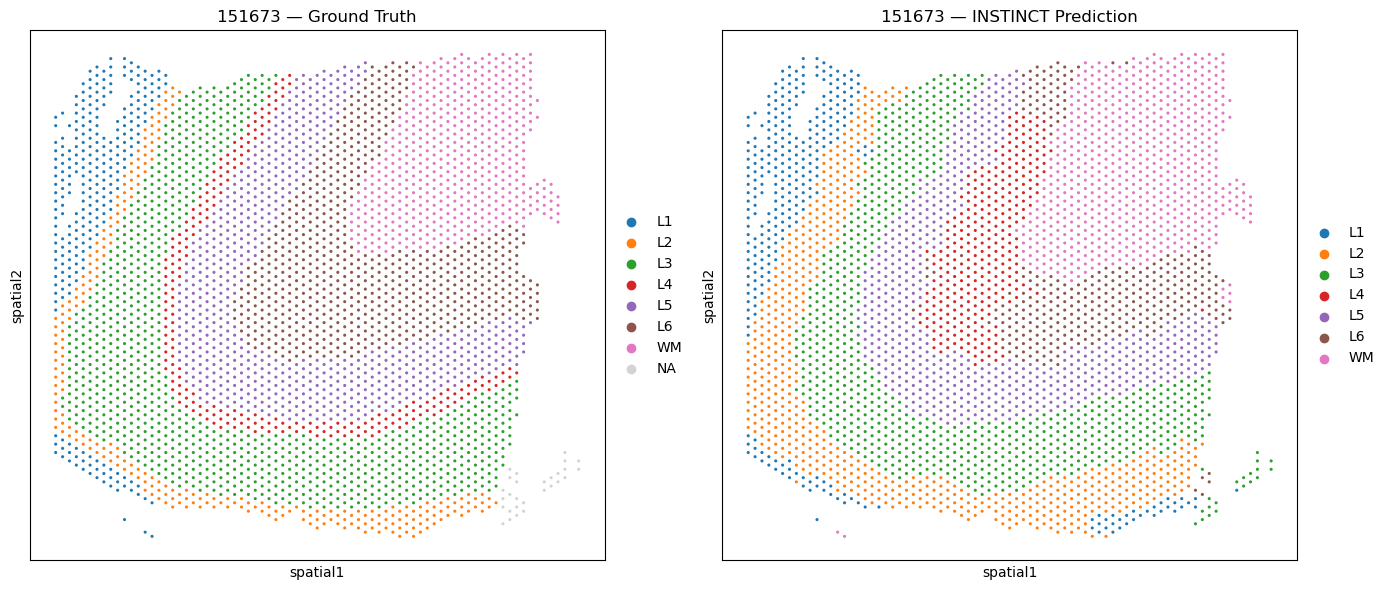

In [11]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct")

SAMPLE_ID = "151673"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_slice = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")
adata = sc.read_h5ad(DATA_ROOT / f"SCE_{SAMPLE_ID}.h5ad")

adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm:
    adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sc.pl.embedding(
    adata, basis="spatial", color="true_label",
    ax=axes[0], show=False, title=f"{SAMPLE_ID} — Ground Truth", s=20,
)
sc.pl.embedding(
    adata, basis="spatial", color="pred_label",
    ax=axes[1], show=False, title=f"{SAMPLE_ID} — INSTINCT Prediction", s=20,
)
axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()


# Donor-level 4-slice visualization (reads parquet only; no files saved)

... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical
... storing 'true_label' as categorical
... storing 'pred_label' as categorical


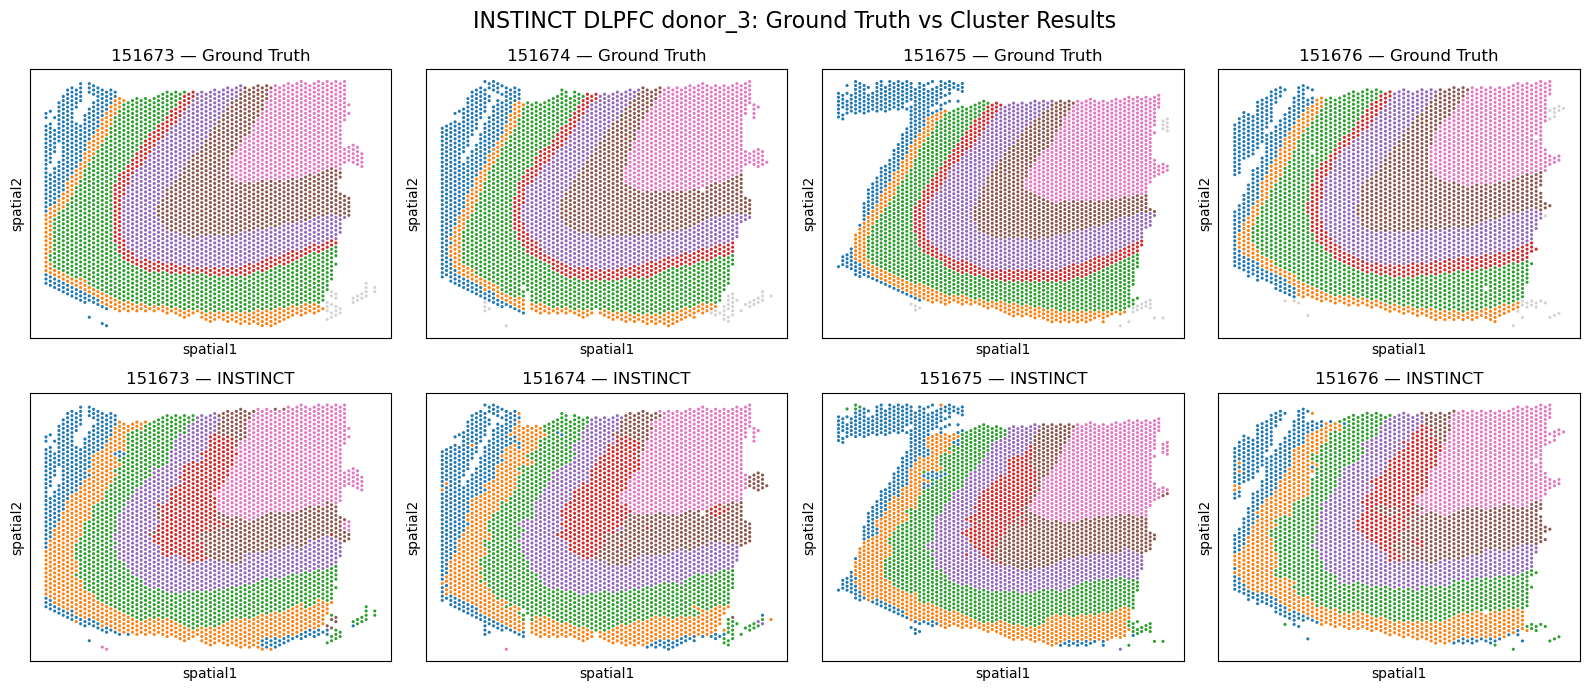

In [12]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/DLPFC_10x/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct")

DONOR_TO_PLOT = "donor_3"
SAMPLES_TO_PLOT = {
    "donor_1": ["151507", "151508", "151509", "151510"],
    "donor_2": ["151669", "151670", "151671", "151672"],
    "donor_3": ["151673", "151674", "151675", "151676"],
}[DONOR_TO_PLOT]

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")

fig, axes = plt.subplots(2, len(SAMPLES_TO_PLOT), figsize=(4 * len(SAMPLES_TO_PLOT), 7))
fig.suptitle(f"INSTINCT DLPFC {DONOR_TO_PLOT}: Ground Truth vs Cluster Results", fontsize=16)

for j, sample_id in enumerate(SAMPLES_TO_PLOT):
    pred_slice = predictions[predictions["sample"] == sample_id].set_index("spot_id")
    adata = sc.read_h5ad(DATA_ROOT / f"SCE_{sample_id}.h5ad")

    adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
    adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

    if "spatial" not in adata.obsm:
        adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

    sc.pl.embedding(
        adata, basis="spatial", color="true_label",
        ax=axes[0, j], show=False, title=f"{sample_id} — Ground Truth", s=20,
        legend_loc=None,
    )
    sc.pl.embedding(
        adata, basis="spatial", color="pred_label",
        ax=axes[1, j], show=False, title=f"{sample_id} — INSTINCT", s=20,
        legend_loc=None,
    )
    axes[0, j].invert_yaxis()
    axes[1, j].invert_yaxis()

plt.tight_layout()
plt.show()


# Running results summary

In [13]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/INSTINCT/dlpfc_instinct")
perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["training_unit", "sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "training_unit", "sample", "run_seed",
    "ARI", "NMI", "ACC", "DIS",
    "AMI", "FMI", "HOM", "COM",
    "num_clusters", "num_spots", "num_labeled_spots",
    "running_time_sec", "donor_running_time_sec",
    "clust_method", "gpu_model",
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All INSTINCT donor-level DLPFC results =====")
display(performance[display_cols])

print("\n===== Summary =====")
summary_cols = [c for c in ["ARI", "NMI", "ACC", "DIS", "AMI", "FMI", "HOM", "COM", "running_time_sec"] if c in performance.columns]
summary = performance[summary_cols].describe()
display(summary)

print("\n===== Mean metrics =====")
print(f"Mean ARI: {performance['ARI'].mean():.4f}")
print(f"Mean NMI: {performance['NMI'].mean():.4f}")
print(f"Mean ACC: {performance['ACC'].mean():.4f}")
if "AMI" in performance.columns:
    print(f"Mean AMI: {performance['AMI'].mean():.4f}")
if "FMI" in performance.columns:
    print(f"Mean FMI: {performance['FMI'].mean():.4f}")
if "DIS" in performance.columns:
    print(f"Mean DIS: {performance['DIS'].mean():.4f}")

print("\n===== Donor-level runtime =====")
runtime = performance[["training_unit", "run_seed", "donor_running_time_sec"]].drop_duplicates()
display(runtime)
print(f"Total donor-level runtime: {runtime['donor_running_time_sec'].sum():.2f} sec")

print("\n===== Best / worst ARI =====")
best = performance.loc[performance["ARI"].idxmax()]
worst = performance.loc[performance["ARI"].idxmin()]

print(f"Best ARI : {best['sample']} ({best['training_unit']})  ARI={best['ARI']:.4f}")
print(f"Worst ARI: {worst['sample']} ({worst['training_unit']})  ARI={worst['ARI']:.4f}")


===== All INSTINCT donor-level DLPFC results =====


,training_unit,sample,run_seed,ARI,NMI,ACC,DIS,AMI,FMI,HOM,COM,num_clusters,num_spots,num_labeled_spots,running_time_sec,donor_running_time_sec,clust_method,gpu_model
0,donor_1,151507,0,0.412102,0.643432,0.643433,NaN,0.642594,0.517143,0.642358,0.644510,7,4226,4221,105.52,422.07,GaussianMixture,NVIDIA A30
1,donor_1,151508,0,0.398533,0.621910,0.622150,NaN,0.621048,0.508526,0.637217,0.607322,7,4384,4381,105.52,422.07,GaussianMixture,NVIDIA A30
2,donor_1,151509,0,0.440568,0.640537,0.642166,NaN,0.639749,0.563276,0.682626,0.603336,7,4789,4788,105.52,422.07,GaussianMixture,NVIDIA A30
3,donor_1,151510,0,0.413696,0.614771,0.616177,NaN,0.613883,0.542249,0.652955,0.580806,7,4634,4595,105.52,422.07,GaussianMixture,NVIDIA A30
4,donor_2,151669,0,0.265128,0.532260,0.545846,NaN,0.531239,0.479088,0.658761,0.446517,7,3661,3636,67.44,269.77,GaussianMixture,NVIDIA A30
5,donor_2,151670,0,0.254949,0.505386,0.524017,NaN,0.504229,0.486722,0.655421,0.411246,7,3498,3484,67.44,269.77,GaussianMixture,NVIDIA A30
6,donor_2,151671,0,0.448567,0.632982,0.640648,NaN,0.632305,0.591675,0.730562,0.558398,7,4110,4093,67.44,269.77,GaussianMixture,NVIDIA A30
7,donor_2,151672,0,0.518843,0.651728,0.655042,NaN,0.651045,0.635483,0.713829,0.599567,7,4015,3888,67.44,269.77,GaussianMixture,NVIDIA A30
8,donor_3,151673,0,0.550006,0.691331,0.691495,NaN,0.690492,0.627599,0.704592,0.678561,7,3639,3611,48.51,194.06,GaussianMixture,NVIDIA A30
9,donor_3,151674,0,0.627016,0.733759,0.733876,NaN,0.733050,0.688529,0.745271,0.722597,7,3673,3635,48.51,194.06,GaussianMixture,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,DIS,AMI,FMI,HOM,COM,running_time_sec
count,12.000000,12.000000,12.000000,0.0,12.000000,12.000000,12.000000,12.000000,12.000000
mean,0.458855,0.640006,0.643910,NaN,0.639166,0.579257,0.687406,0.604317,73.823333
std,0.121126,0.068152,0.062895,NaN,0.068260,0.072864,0.037070,0.097327,24.762071
min,0.254949,0.505386,0.524017,NaN,0.504229,0.479088,0.637217,0.411246,48.510000
25%,0.408709,0.620125,0.620657,NaN,0.619257,0.514989,0.654804,0.575204,48.510000
50%,0.444567,0.641984,0.642800,NaN,0.641171,0.577476,0.693609,0.605329,67.440000
75%,0.557026,0.693565,0.693702,NaN,0.692724,0.638444,0.714606,0.682012,105.520000
max,0.627016,0.733759,0.733876,NaN,0.733050,0.688529,0.745271,0.722597,105.520000



===== Mean metrics =====
Mean ARI: 0.4589
Mean NMI: 0.6400
Mean ACC: 0.6439
Mean AMI: 0.6392
Mean FMI: 0.5793
Mean DIS: nan

===== Donor-level runtime =====


,training_unit,run_seed,donor_running_time_sec
0,donor_1,0,422.07
4,donor_2,0,269.77
8,donor_3,0,194.06


Total donor-level runtime: 885.90 sec

===== Best / worst ARI =====
Best ARI : 151674 (donor_3)  ARI=0.6270
Worst ARI: 151670 (donor_2)  ARI=0.2549
